Loaded cached results from /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4/llama-7b/poisson/tp1_instance_profile_results.json


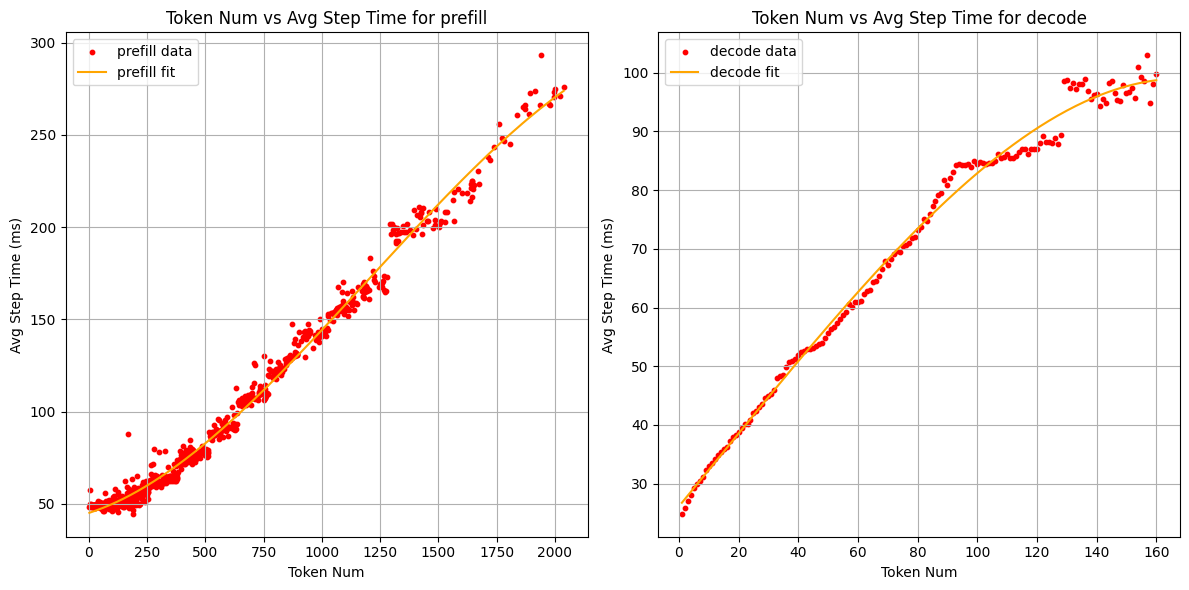

In [10]:

from benchmark_test.analysis.profile import InstanceProfile
import numpy as np
from statistics import mean
import matplotlib.pyplot as plt

instance_file_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4/llama-7b/poisson'
instance_profile = InstanceProfile(instance_file_dir, enable_pd=True)
instance_profile.get_pdd_instance_info()
instance_profile.plot_token_num_vs_avg_step_time()

Processing concurrency: 1
Loaded cached results from /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4/llama-7b/poisson/tp1_instance_profile_results.json
Inference Type: prefill
Inference Type: decode
Processing concurrency: 2
Loaded cached results from /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-2-pdd-4/llama-7b/poisson/tp1_instance_profile_results.json
Inference Type: prefill
Inference Type: decode
Processing concurrency: 4
Loaded cached results from /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-4-pdd-4/llama-7b/poisson/tp1_instance_profile_results.json
Inference Type: prefill
Inference Type: decode
Processing concurrency: 8
Loaded cached results from /workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-8-pdd-4/llama-7b/poisson/tp1_instance_profile_results.json
Inference Type: prefill
Inference Type: decode
Lower bound: -79.73179552290176, Upper bound: 320.907314

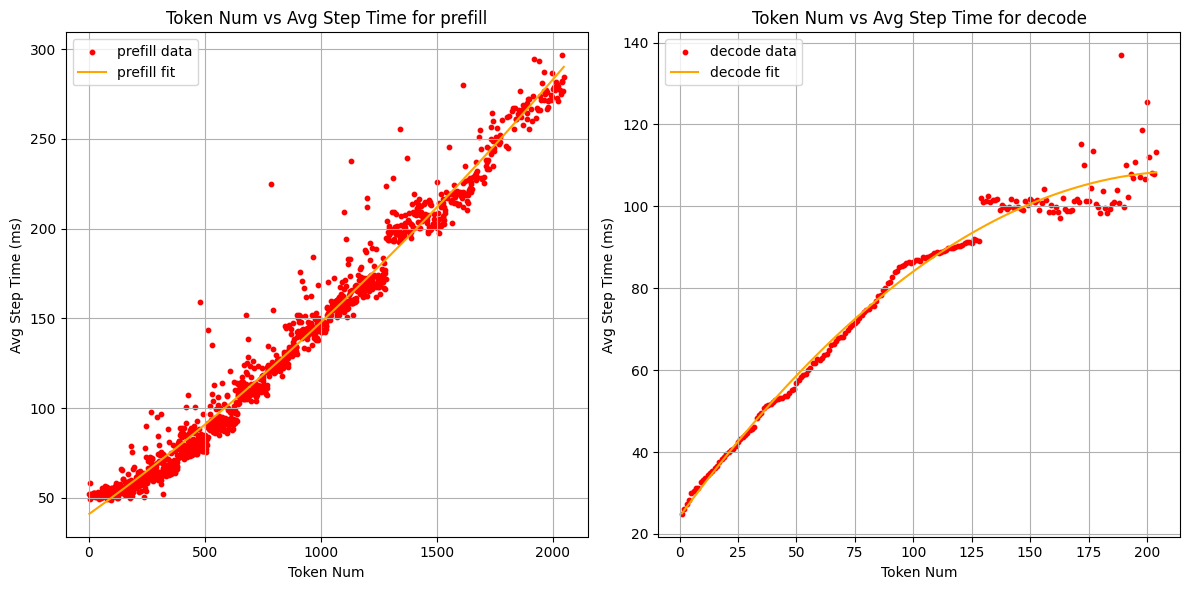

In [23]:
def calculate_avg_step_time(results):
    # 计算每个inference_type和token_num的平均step_time
    avg_results = {
        'prefill': {},
        'decode': {},
    }
    for inference_type in results:
        for token_num, step_times in results[inference_type].items():
            step_times = np.array(step_times, dtype=float)
            avg_step_time = mean(step_times)
            avg_results[inference_type][token_num] = avg_step_time
    return avg_results

# 拟合token_num和avg_step_time的关系
def fit_token_num_vs_avg_step_time(token_nums, avg_step_times, inference_type):

    if len(token_nums) < 2:
        print(f"Not enough data to fit for {inference_type}.")
        return None
    
    # 使用numpy的polyfit进行线性拟合
    if inference_type == 'prefill':
        # 线性拟合
        coefficients = np.polyfit(token_nums, avg_step_times, 2)
    elif inference_type == 'decode':
        # 二次多项式拟合
        coefficients = np.polyfit(token_nums, avg_step_times, 2)
    fit_results = coefficients
    return fit_results

# 绘制token_num和avg_step_time的关系图,使用matplotlib,
def plot_token_num_vs_avg_step_time(results):
    avg_results = calculate_avg_step_time(results)
    # 分配两个子图
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    for i, inference_type in enumerate(avg_results):
        token_nums = list(avg_results[inference_type].keys())
        avg_step_times = list(avg_results[inference_type].values())

        token_nums = np.array(token_nums, dtype=float)
        avg_step_times = np.array(avg_step_times, dtype=float)

        sort_idx = np.argsort(token_nums)
        token_nums = token_nums[sort_idx]
        avg_step_times = avg_step_times[sort_idx]

        # 剔除异常值
        if len(token_nums) > 2:
            # 基于IQR方法剔除异常值
            q1 = np.percentile(avg_step_times, 25)
            q3 = np.percentile(avg_step_times, 75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
            mask = (avg_step_times >= lower_bound) & (avg_step_times <= upper_bound)
            token_nums = token_nums[mask]
            avg_step_times = avg_step_times[mask]
        axs[i].scatter(token_nums, avg_step_times, label=f'{inference_type} data', color='red', s=10)
        # 拟合曲线
        fit_results = fit_token_num_vs_avg_step_time(token_nums, avg_step_times, inference_type)
        if fit_results is not None:
            print(f'Fitting results for {inference_type}: {fit_results}')
            fit_line = np.polyval(fit_results, token_nums)
            axs[i].plot(token_nums, fit_line, label=f'{inference_type} fit', color='orange')
        axs[i].set_title(f'Token Num vs Avg Step Time for {inference_type}')
        axs[i].set_xlabel('Token Num')
        axs[i].set_ylabel('Avg Step Time (ms)')
        axs[i].legend()
        axs[i].grid(True)
    plt.tight_layout()
    plt.savefig(f'token_num_vs_avg_step_time.png')
    plt.show()
    
results = {        # [inference_type][token_num] = step_time:list
    'prefill': {},
    'decode': {},
}
for concurrency in [1, 2, 4, 8]:
    print(f"Processing concurrency: {concurrency}")
    instance_file_dir = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-{concurrency}-pdd-4/llama-7b/poisson'
    instance_profile = InstanceProfile(instance_file_dir, enable_pd=True)
    instance_profile.get_pdd_instance_info()
    # instance_profile.plot_token_num_vs_avg_step_time()
    for inference_type in instance_profile.results:
        print(f'Inference Type: {inference_type}')
        for token_num, avg_step_time in instance_profile.results[inference_type].items():
            if token_num not in results[inference_type]:
                results[inference_type][token_num] = []
            results[inference_type][token_num].extend(instance_profile.results[inference_type][token_num])
plot_token_num_vs_avg_step_time(results)